# Trabajo Final

## Introducción
En una planta de manufactura se registran los eventos que interrumpen cada proceso de producción.

## 01. Carga de librerías y dataset

In [281]:
# Con Windows para K-means, limitar el uso de núcleos del procesador
import os
os.environ["OMP_NUM_THREADS"] = "1"

# Importar librerías
#!pip install prince
import prince
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import levene
from scipy import stats
from scipy.stats import f_oneway

In [282]:
#Cargamos el archivo que contiene la base de datos, seleccionando la hoja que se usará como base.
df = pd.read_excel('Dataset Proyecto Final.xlsx', sheet_name='Eventos de perdida')

## 02. Inspección de datos

Comprobamos que se haya cargado correctamente, y hacemos un análisis general del dataframe

In [285]:
print(df.head())
print(df.info())

   Loss event ID    Process  Machine       Date Shift Part code  \
0              1  Process A   Load A 2024-07-01   1st    Cab123   
1              2  Process A   Load A 2024-07-01   2nd    Cab456   
2              3  Process B  Main B2 2024-07-01   1st    Door89   
3              4  Process C   Load C 2024-07-01   2nd      Com1   
4              5  Process B  Main B1 2024-07-02   1st    Door89   

   duration (minutes)          OEE LOSS TYPE  Impacto por minuto  \
0                  35              Breakdown           25.000000   
1                  30     Planned Changeover           30.000000   
2                  43   Unplanned Changeover           15.789474   
3                  55  Setup and adjustments           17.272727   
4                  15       Tool Replacement           15.789474   

   $ LOSS (Impacto en KPI Financiero)  por tiempo perdido  SCRAP parts  \
0                                         875.000000                 0   
1                                       

Después de correr las validaciones detectamos que no hay valores nulos. Procedemos a hacer validación de valores duplicados.

In [287]:
df[df.duplicated()]

,Loss event ID,Process,Machine,Date,Shift,Part code,duration (minutes),OEE LOSS TYPE,Impacto por minuto,$ LOSS (Impacto en KPI Financiero) por tiempo perdido,SCRAP parts,REWORK parts


Confirmamos que no hay ningún valor duplicado en nuestra base de datos. Ahora revisaremos si hay datos perdidos.

In [289]:
df[df.isna().any(axis=1)]

,Loss event ID,Process,Machine,Date,Shift,Part code,duration (minutes),OEE LOSS TYPE,Impacto por minuto,$ LOSS (Impacto en KPI Financiero) por tiempo perdido,SCRAP parts,REWORK parts


Confirmamos que no hay ningún dato perdido en la base.

## 03. Análisis del DF con Gráficos

Como parte de la exploración inicial, se hace un análisis mediante una tabla pivote, y un par de gráfico de barras para tener un panorama general de los datos

### Tabla Dinámica del impacto financiero

In [294]:
tabla = df.pivot_table(index='OEE LOSS TYPE', columns='Process', values='$ LOSS (Impacto en KPI Financiero)  por tiempo perdido', aggfunc='sum')
tabla['Total'] = tabla.sum(axis=1)
tabla_formato = tabla.applymap(lambda x: f'{x:,.2f}' if pd.notnull(x) else x)
tabla_formato

Process,Process A,Process B,Process C,Total
OEE LOSS TYPE,,,,
Breakdown,"2,975.00","2,892.98","2,414.77","8,282.76"
Lack of Quality,120.00,690.06,87.50,897.56
Lack of material,"3,960.00",711.11,"2,711.82","7,382.93"
Lack of operators,"3,725.00",205.26,175.00,"4,105.26"
Line Blocked,565.00,157.89,295.91,"1,018.80"
Line Starved,"1,025.00",NaN,207.27,"1,232.27"
Micro Stoppages,125.00,"1,057.89",NaN,"1,182.89"
Planned Changeover,"4,500.00",789.47,259.09,"5,548.56"
Setup and adjustments,"1,885.00",755.56,"1,995.00","4,635.56"


Esta tabla nos ayuda a tener una vista rápida del impacto financiero en cada Proceso dependiendo el Tipo de Falla.

### Top Offenders - Gráfico de Barras
Ahora graficaremos los Top Offenders con un gráfico de barras

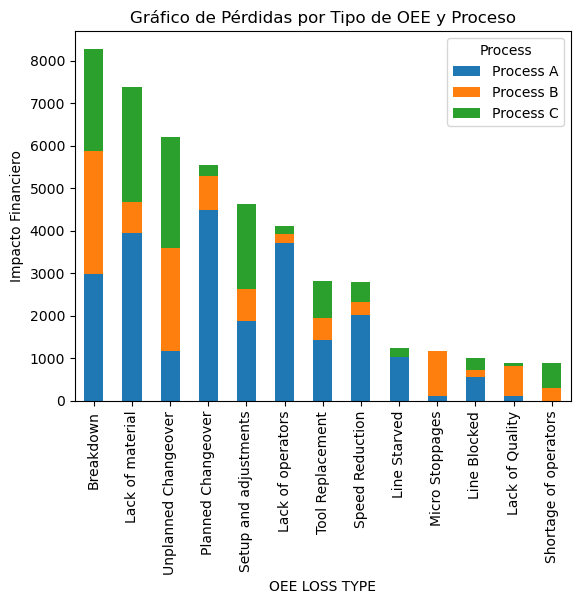

In [297]:
tabla_sorted = tabla.sort_values(by='Total', ascending=False)
tabla_sorted_for_plot = tabla_sorted.drop(columns=['Total'])
tabla_sorted_for_plot.plot(kind='bar', stacked=True)
plt.ylabel('Impacto Financiero')
plt.title('Gráfico de Pérdidas por Tipo de OEE y Proceso')
plt.show()

Con este gráfico, podemos visualizar que el Tipo de pérdida que tiene un mayor efecto, es el Breakdowon, seguido del Lack of Material.

### # de fallas por proceso - Gráfico de Barras
Finalmente, graficaremos el número de fallas en cada proceso.

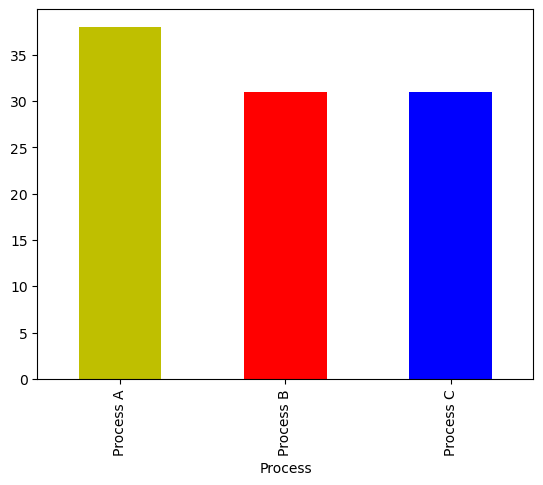

In [300]:
df['Process'].value_counts().plot(kind = 'bar', width = 0.50, alpha = 1, color = ['y', 'r', 'b']);

En el gráfico, podemos observar que el proceso A es el que más fallas tiene, y el proceso B y C tienen el mismo número de fallas.

### Tabla de Promedios y Desviación Estándar
Haremos un análisis de los promedios y la desviación estándar de cada tipo de fallas, considerando la variable dependiente de la duración de la falla.

In [303]:
table2 = df.groupby('OEE LOSS TYPE')['duration (minutes)'].agg(['mean', 'std'])
table2

,mean,std
OEE LOSS TYPE,,
Breakdown,50.500000,12.739141
Lack of Quality,6.714286,2.288689
Lack of material,41.250000,26.184783
Lack of operators,20.375000,23.645824
Line Blocked,6.857143,2.267787
Line Starved,7.428571,2.760262
Micro Stoppages,7.625000,2.503569
Planned Changeover,26.875000,5.303301
Setup and adjustments,27.000000,12.547054


Esta tabla nos ayuda a ver el promedio de duración de cada tipo de fallas, así como su variación. Para entenderlo mejor, procedemos a graficar la información.

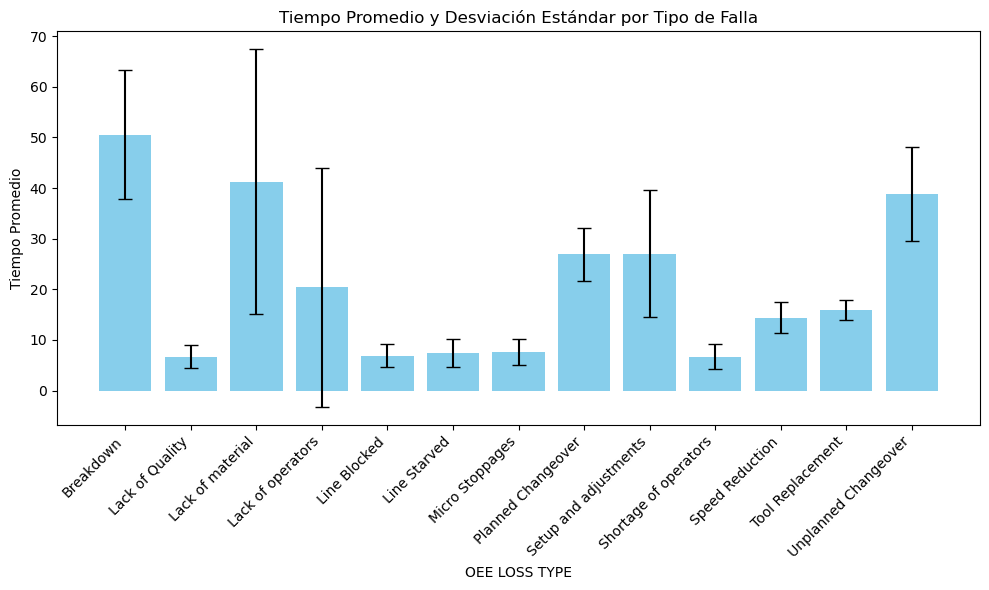

In [305]:
# Agrupación
table2 = df.groupby('OEE LOSS TYPE')['duration (minutes)'].agg(['mean', 'std'])

# Crear el gráfico de barras con barras de error
plt.figure(figsize=(10, 6))
plt.bar(table2.index, table2['mean'], yerr=table2['std'], capsize=5, color='skyblue')

# Etiquetas y título
plt.xlabel('OEE LOSS TYPE')
plt.ylabel('Tiempo Promedio')
plt.title('Tiempo Promedio y Desviación Estándar por Tipo de Falla')
plt.xticks(rotation=45, ha='right')

# Mostrar el resultado
plt.tight_layout()
plt.show()

Observamos grandes diferencias en los tiempos promedio entre los distintos tipos de fallas. Algunas fallas, como Breakdown, Lack of Material, y Unplanned Changeover, tienen tiempos promedio significativamente más altos en comparación con otras fallas como Lack of Quality, Micro Stoppages, y Tool Replacement.

Las fallas con menores tiempos y variabilidad, aunque más consistentes, podrían ser optimizadas para mejorar aún más el rendimiento del sistema.

## 04. Análisis de correspondencia

Para entrar más a detalle en el análisis de nuestro df, haremos un análisis de correspondencia que nos ayude a evaluar la relación entre nuestras variables.

Para esto, convertimos nuestra variable 'duration (minutes)' en una variable cualitativa.

In [309]:
bins = [0, 5, 10, 19, 30, 100]  # Intervalos para dividir los tiempos
labels = ['Muy Breve', 'Breve', 'Regular', 'Tardado', 'Muy Tardado']  # Nombres de las categorías

Una vez definidas nuestras categorías, agregamos a nuestro df estas categorías

In [311]:
df['Categoría Minutos'] = pd.cut(df['duration (minutes)'], bins=bins, labels=labels, right=False)

Una vez actualizado nuestro df con esta nueva categoría, corremos el modelo de análisis de correspondencia.

In [313]:
warnings.filterwarnings("ignore", category=FutureWarning)
var_cat = ['Categoría Minutos', 'Shift', 'Process']

# Creación de instancia del modelo
mca = prince.MCA(n_components = 2)
# Ajuste del modelo a los datos
mca = mca.fit(df[var_cat])
# Crea gráfico
ax = mca.plot(df[var_cat], show_column_labels=True, show_row_markers=False)
ax

alt.LayerChart(...)

Este gráfico de MCA proporciona una visualización de las relaciones entre las categorías de las variables, mostrando asociaciones clave. Las categorías cercanas indican patrones similares o una alta probabilidad de ocurrir juntas, mientras que las categorías más alejadas muestran diferencias o falta de relación entre sí.

**Observaciones**
Process C está más cerca de las categorías de minutos Regular y Muy Breve, lo que podría indicar que este proceso tiende a estar asociado con eventos de menor duración.
Las categorías de minutos Muy Tardado y Tardado están más relacionadas con Process A, lo que sugiere que este proceso puede estar vinculado con eventos de mayor duración.


## 05. ANOVA
Se verificará si hay una variacion significativa en el impacto de perdidas entre el primero y el segundo turno. Esto se hará mediante un ANOVA.

### Supuesto de igualdad de varianzas

Empezamos haciendo el supuesto de igualdad de varianzas. Filtramos los datos para obtener los grupos por turno.

In [318]:
Turno1 = df[df['Shift'] == '1st']['duration (minutes)']
Turno2 = df[df['Shift'] == '2nd']['duration (minutes)']

Realizamos la prueba del p-valor para comprobar la hipótesis alternativa de que hay evidencia de diferencias significativas en las varianzas.

In [320]:
# Realizar la prueba
statistic, p_value = levene(Turno1, Turno1)
print("Estadístico de prueba de Levene:", statistic)
print("Valor p:", p_value)

# Interpretar los resultados
alpha = 0.05
if p_value < alpha:
    print("Se rechaza la hipótesis nula: hay evidencia de diferencias significativas en las varianzas.")
else:
    print("No se puede rechazar la hipótesis nula: no se rechaza el supuesto de igualdad de varianzas.")

Estadístico de prueba de Levene: 0.0
Valor p: 1.0
No se puede rechazar la hipótesis nula: no se rechaza el supuesto de igualdad de varianzas.


**No rechazamos la hipótesis nula.**

### Supuesto de normalidad

In [323]:
def test_normality(data):
    mean = data.mean()
    std = data.std()
    return stats.kstest(data, 'norm', args=(mean, std))

# Realizar la prueba K-S para cada turno
for turno in df['Shift'].unique():
    OEE_loss = df[df['Shift'] == turno]['duration (minutes)']
    stat, p_value = test_normality(OEE_loss)
    print(f'Turno {turno}: Estadístico K-S = {stat}, Valor p = {p_value}')

Turno 1st: Estadístico K-S = 0.2217873805345032, Valor p = 0.011021969119721198
Turno 2nd: Estadístico K-S = 0.15079078875192753, Valor p = 0.1943412682990897


**Para el primer turno, los datos no siguen una distribución normal.**

**Para el segundo turno, los datos podrían seguir una distribución normal, ya que el valor p no es significativo.**

### Cálculo de ANOVA

In [326]:
# Aplicar la prueba ANOVA
statistic, p_value = f_oneway(Turno1, Turno2)

# Imprimir los resultados
print("Estadístico de prueba de ANOVA:", statistic)
print("Valor p:", p_value)

Estadístico de prueba de ANOVA: 0.16652697541217928
Valor p: 0.6841072231447131


**Interpretación**

Estadístico de prueba de ANOVA (0.1327): Un valor pequeño indica que no hay una gran variabilidad entre las medias de los Turnos en relación con la variabilidad dentro de los grupos. Esto sugiere que las medias de las duraciones de los eventos en los turnos no son muy diferentes entre sí.

Valor p (0.7164): El valor p es mucho mayor que el nivel de significancia (0.05). Esto significa que no hay evidencia suficiente para rechazar la hipótesis nula de que las medias de duración de los eventos son iguales entre los dos turnos.

**Conclusión de la ANOVA**

La prueba ANOVA sugiere que no hay una diferencia estadísticamente significativa en la duración promedio de los eventos entre los turnos 1 y 2. Es decir, las duraciones de los eventos en los dos turnos son similares en promedio.

## 06. Análisis de Regresión Lineal

Por último, se hace un análisis de regresión lineal que busca explicar la variable dependiente 'duration (minutes'.

### Tamaño muestral

Se evalua si hay suficientes observaciones de cada variable:

In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   Loss event ID                                           100 non-null    int64         
 1   Process                                                 100 non-null    object        
 2   Machine                                                 100 non-null    object        
 3   Date                                                    100 non-null    datetime64[ns]
 4   Shift                                                   100 non-null    object        
 5   Part code                                               100 non-null    object        
 6   duration (minutes)                                      100 non-null    int64         
 7   OEE LOSS TYPE                                           100 non


Confirmamos que el tamaño de la muestra es adecuada para evaluar los coeficientes de regresión de cada variable.

### Variables dicotómicas

Para el análisis de regresión lineal, crearemos variables dicotómicas para "Process", con el fin de poder usar esta variable en el modelo de regresión.

In [335]:
df = pd.get_dummies(df, columns=['Process'], prefix='',  
                    dtype=int, drop_first=True)
df = pd.get_dummies(df, columns=['OEE LOSS TYPE'], prefix='TP',  
                    dtype=int, drop_first=True)
df.head(3)

,Loss event ID,Machine,Date,Shift,Part code,duration (minutes),Impacto por minuto,$ LOSS (Impacto en KPI Financiero) por tiempo perdido,SCRAP parts,REWORK parts,...,TP_Lack of operators,TP_Line Blocked,TP_Line Starved,TP_Micro Stoppages,TP_Planned Changeover,TP_Setup and adjustments,TP_Shortage of operators,TP_Speed Reduction,TP_Tool Replacement,TP_Unplanned Changeover
0,1,Load A,2024-07-01,1st,Cab123,35,25.000000,875.000000,0,2,...,0,0,0,0,0,0,0,0,0,0
1,2,Load A,2024-07-01,2nd,Cab456,30,30.000000,900.000000,1,2,...,0,0,0,0,1,0,0,0,0,0
2,3,Main B2,2024-07-01,1st,Door89,43,15.789474,678.947368,5,1,...,0,0,0,0,0,0,0,0,0,1


### Estadística descriptiva

Se obtiene la estadística descriptiva del data frame:

In [338]:
var_cont = df[['duration (minutes)', '_Process B', '_Process C', 'TP_Lack of Quality',
       'TP_Lack of material', 'TP_Lack of operators', 'TP_Line Blocked',
       'TP_Line Starved', 'TP_Micro Stoppages', 'TP_Planned Changeover',
       'TP_Setup and adjustments', 'TP_Shortage of operators',
       'TP_Speed Reduction', 'TP_Tool Replacement', 'TP_Unplanned Changeover']]
var_cont.describe().T

,count,mean,std,min,25%,50%,75%,max
duration (minutes),100.0,21.36,18.236671,1.0,8.0,15.0,30.0,81.0
_Process B,100.0,0.31,0.464823,0.0,0.0,0.0,1.0,1.0
_Process C,100.0,0.31,0.464823,0.0,0.0,0.0,1.0,1.0
TP_Lack of Quality,100.0,0.07,0.256432,0.0,0.0,0.0,0.0,1.0
TP_Lack of material,100.0,0.08,0.272660,0.0,0.0,0.0,0.0,1.0
TP_Lack of operators,100.0,0.08,0.272660,0.0,0.0,0.0,0.0,1.0
TP_Line Blocked,100.0,0.07,0.256432,0.0,0.0,0.0,0.0,1.0
TP_Line Starved,100.0,0.07,0.256432,0.0,0.0,0.0,0.0,1.0
TP_Micro Stoppages,100.0,0.08,0.272660,0.0,0.0,0.0,0.0,1.0
TP_Planned Changeover,100.0,0.08,0.272660,0.0,0.0,0.0,0.0,1.0


### Evaluación del ajuste del modelo

Creamos un DataFrame con las variables independientes y la variable dependiente.

In [341]:
X = df[['_Process B', '_Process C', 'TP_Lack of Quality',
       'TP_Lack of material', 'TP_Lack of operators', 'TP_Line Blocked',
       'TP_Line Starved', 'TP_Micro Stoppages', 'TP_Planned Changeover',
       'TP_Setup and adjustments', 'TP_Shortage of operators',
       'TP_Speed Reduction', 'TP_Tool Replacement', 'TP_Unplanned Changeover']]
X = sm.add_constant(X)
y = df['duration (minutes)']

Corremos modelo de regresión mediante mínimos cuadrados ordinarios, y vemos el resumen del mismo

In [343]:
regresion = sm.OLS(y, X).fit()
regresion.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     duration (minutes)   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     10.58
Date:                Tue, 20 Aug 2024   Prob (F-statistic):           2.22e-13
Time:                        23:37:25   Log-Likelihood:                -381.28
No. Observations:                 100   AIC:                             792.6
Df Residuals:                      85   BIC:                             831.6
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       50.6673      4.684     10.817      0.000      41.354      59.980
_Process B                  -0.9879      3.338     -0.296      0.768      -7.625       5.650
_Process C                   0.5419      3.128      0.173      0.863      -5.677       6.761
TP_Lack of Quality         -43.3247      6.236     -6.948      0.000     -55.723     -30.927
TP_Lack of material         -9.4292      6.038     -1.562      0.122     -21.434       2.575
TP_Lack of operators       -30.1808      5.982     -5.045      0.000     -42.074     -18.287
TP_Line Blocked            -43.6827      6.170     -7.080      0.000     -55.950     -31.415
TP_Line Starved            -43.3935      6.308     -6.879      0.000     -55.936     -30.851
TP_Micro Stoppages         -42.1779      6.138     -6.872      0.000     -54.382     -29.974
TP_Planned Changeover      -23.6130      6.032     -3.914      0.000     -35.607     -11.619
TP_Setup and adjustments   -23.8147      5.988     -3.977      0.000     -35.720     -11.909
TP_Shortage of operators   -44.0578      6.225     -7.077      0.000     -56.435     -31.681
TP_Speed Reduction         -36.3042      6.038     -6.013      0.000     -48.309     -24.300
TP_Tool Replacement        -34.7485      5.956     -5.834      0.000     -46.592     -22.905
TP_Unplanned Changeover    -11.6927      5.955     -1.964      0.053     -23.532       0.147
==============================================================================
Omnibus:                       38.168   Durbin-Watson:                   1.816
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              126.830
Skew:                           1.248   Prob(JB):                     2.88e-28
Kurtosis:                       7.920   Cond. No.                         15.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretación de la R-Cuadrada.

La R-cuadrada del modelo, con un valor de 0.634, sugiere que el modelo puede explicar casi el 64% de la variación en la duración en minutos de la falla. Sin embargo, hay un 36% de la variación que no está explicada por estas variables, lo que sugiere que puede haber otros factores relevantes que no están incluidos en el modelo.

### Interpretación del p-valor del estadístico F.

El p-valor de 2.22e-13 indica que el modelo en su conjunto es altamente significativo. Es decir, las variables independientes en conjunto tienen un efecto significativo sobre la variable dependiente.

### Interpretación de las variables Dummy
***Proceso***
    El Proceso B y Proceso C, no muestran significancia estadística (ya que su p-valor es > 0.05), lo que indica que no podemos concluir que sean diferentes a _Process A.
    
***Tipos de pérdidas***
    La mayoría de las variables dummy como 'TP_Lack of Quality', 'TP_Line Blocked', 'TP_Line Starved', tienen coeficientes negativos significativos, lo que indica que, en general, estas pérdidas tienden a reducir la pérdida financiera en comparación con 'TP_Breakdown'.